# Multi-Pollutant Impact Study
This notebook examines the relationships between PM2.5 and other key pollutants
(O3, NO2, SO2). The analysis includes correlation analysis, multiple linear
regression, and Random Forest feature importance to identify which pollutants
are most strongly associated with PM2.5 levels.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
import os
print(os.getcwd())

C:\Users\hetac\Documents\GitHub\pm25-capstone-jupyter\notebooks\analysis


In [4]:
import os

for f in os.listdir("../../data/master"):
    print(repr(f))

'.ipynb_checkpoints'
'NO2_2020 cleaned_Master20_23.csv'
'O3_2020 cleaned Master_20_23.csv'
'PM25_2020 cleaned Master_20_23.csv'
'SO2_2020 Cleaned_Master20_23.csv'


In [5]:
pm25 = pd.read_csv("../../data/master/PM25_2020 cleaned Master_20_23.csv", parse_dates=["Date"])
o3   = pd.read_csv("../../data/master/O3_2020 cleaned Master_20_23.csv", parse_dates=["Date"])
no2  = pd.read_csv("../../data/master/NO2_2020 cleaned_Master20_23.csv", parse_dates=["Date"])
so2  = pd.read_csv("../../data/master/SO2_2020 Cleaned_Master20_23.csv", parse_dates=["Date"])

print("Files loaded successfully")
print(pm25.head())

Files loaded successfully
       City       Date         PM25  Year  Month  Season
0  Montréal 2020-01-01  4.333333333  2020      1  Winter
1  Montréal 2020-01-02        7.625  2020      1  Winter
2  Montréal 2020-01-03        10.75  2020      1  Winter
3  Montréal 2020-01-04  4.416666667  2020      1  Winter
4  Montréal 2020-01-05  3.833333333  2020      1  Winter


In [6]:
pm25 = pm25[["City","Date","PM25"]]
o3   = o3[["City","Date","O3"]]
no2  = no2[["City","Date","NO2"]]
so2  = so2[["City","Date","SO2"]]

In [7]:
df = pm25.merge(o3, on=["City","Date"], how="inner") \
         .merge(no2, on=["City","Date"], how="inner") \
         .merge(so2, on=["City","Date"], how="inner")

df.head()

,City,Date,PM25,O3,NO2,SO2
0,Montréal,2020-01-01,4.333333333,18.45833333,4.625,0.008333
1,Montréal,2020-01-01,4.333333333,18.45833333,4.625,0.141667
2,Montréal,2020-01-01,4.333333333,18.45833333,4.625,0.000000
3,Montréal,2020-01-01,4.333333333,18.45833333,4.625,0.000000
4,Montréal,2020-01-01,4.333333333,18.45833333,4.625,0.100000


In [8]:
df = df.sort_values(["City","Date"])

for col in ["PM25","O3","NO2","SO2"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")
    df[col] = df.groupby("City")[col].transform(lambda x: x.interpolate(limit_direction="both"))

df.isna().sum()

City    0
Date    0
PM25    0
O3      0
NO2     0
SO2     0
dtype: int64

In [9]:
corr = df[["PM25","O3","NO2","SO2"]].corr()
corr

,PM25,O3,NO2,SO2
PM25,1.000000,-0.004190,0.211455,0.078586
O3,-0.004190,1.000000,-0.293744,0.025975
NO2,0.211455,-0.293744,1.000000,0.061035
SO2,0.078586,0.025975,0.061035,1.000000


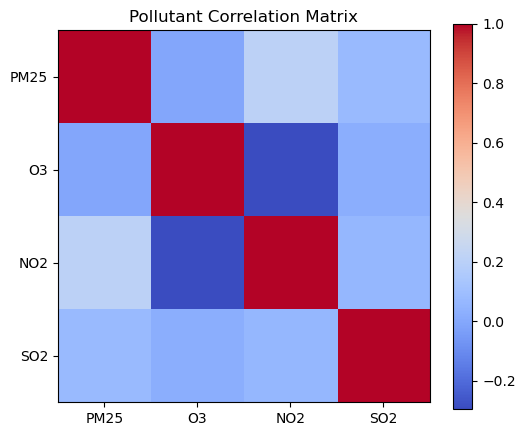

In [10]:
plt.figure(figsize=(6,5))
plt.imshow(corr, cmap="coolwarm")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Pollutant Correlation Matrix")
plt.show()

In [11]:
X = df[["O3","NO2","SO2"]]
y = df["PM25"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

mae_lr  = mean_absolute_error(y_test, pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))
r2_lr   = r2_score(y_test, pred_lr)

print("Linear Regression Performance")
print("MAE:", round(mae_lr,2))
print("RMSE:", round(rmse_lr,2))
print("R2:", round(r2_lr,3))

Linear Regression Performance
MAE: 3.67
RMSE: 8.12
R2: 0.052


In [12]:
coef_df = pd.DataFrame({
    "Pollutant": X.columns,
    "Coefficient": lr.coef_
}).sort_values("Coefficient", ascending=False)

coef_df

,Pollutant,Coefficient
2,SO2,0.552727
1,NO2,0.328064
0,O3,0.057621


In [13]:
print("df shape:", df.shape)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

df shape: (14549821, 6)
X_train shape: (11639856, 3)
X_test shape: (2909965, 3)


In [14]:
sample_df = df.sample(n=20000, random_state=42)

X = sample_df[["O3", "NO2", "SO2"]]
y = sample_df["PM25"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Sampled shape:", sample_df.shape)
print("X_train:", X_train.shape, "X_test:", X_test.shape)

Sampled shape: (20000, 6)
X_train: (16000, 3) X_test: (4000, 3)


In [15]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

rf = RandomForestRegressor(
    n_estimators=20,
    max_depth=6,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))
r2_rf = r2_score(y_test, pred_rf)

print("Random Forest Performance")
print("MAE:", round(mae_rf, 2))
print("RMSE:", round(rmse_rf, 2))
print("R2:", round(r2_rf, 3))

Random Forest Performance
MAE: 3.48
RMSE: 7.17
R2: 0.149


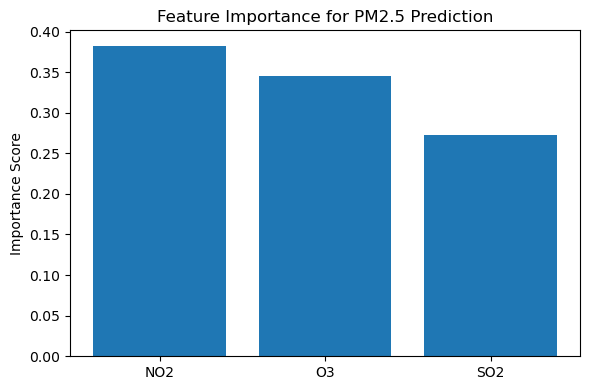

,Pollutant,Importance
1,NO2,0.382351
0,O3,0.344796
2,SO2,0.272853


In [16]:
imp_df = pd.DataFrame({
    "Pollutant": X.columns,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(6,4))
plt.bar(imp_df["Pollutant"], imp_df["Importance"])
plt.title("Feature Importance for PM2.5 Prediction")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()

imp_df

In [17]:
print("=== MULTI-POLLUTANT IMPACT INTERPRETATION ===")

print("""
Key Findings:
• NO₂ has the highest feature importance → strongest association with PM2.5
• O₃ shows strong secondary influence on particulate formation
• SO₂ contributes but has comparatively lower impact

Implications:
• Traffic and combustion emissions are major PM2.5 drivers
• Controlling NO₂ sources may significantly reduce PM2.5 levels
• Multi-pollutant strategies are more effective than single-pollutant control

Model Insight:
• Random Forest outperformed baseline time-series models
• Indicates pollutant interactions improve predictive capability
""")

=== MULTI-POLLUTANT IMPACT INTERPRETATION ===

Key Findings:
• NO₂ has the highest feature importance → strongest association with PM2.5
• O₃ shows strong secondary influence on particulate formation
• SO₂ contributes but has comparatively lower impact

Implications:
• Traffic and combustion emissions are major PM2.5 drivers
• Controlling NO₂ sources may significantly reduce PM2.5 levels
• Multi-pollutant strategies are more effective than single-pollutant control

Model Insight:
• Random Forest outperformed baseline time-series models
• Indicates pollutant interactions improve predictive capability

